# Modelagem probabilística de dados físicos com a GLD: notebook do artigo

Reproduz todos os números, tabelas e figuras do artigo para a RBEF, a partir do arquivo
`estacao_A001_diario.csv` (INMET, estação automática A001, Brasília, DF). Executar do início ao
fim. Cada figura é salva em PNG a 300 dpi, em português (`_pt`), usada no artigo, e em inglês (`_en`).

## **1. Bibliotecas e configuração**

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt

import pyglam as glam
from pyglam import GlamFKML

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'font.size': 10,
})

DATA    = Path('estacao_A001_diario.csv')
OUT     = Path('artigo')              # figuras e tabelas lidas pelo manuscrito
OUT.mkdir(exist_ok=True)
N_STARTS, SEED = 15, 0                # multi-start do ajuste da GLD

# paleta fixa, uma cor por modelo em todas as figuras
color = {'data': '#9c9a91', 'gld': '#2a78d6', 'rayleigh': '#eb6834', 'weibull': '#1baf7a',
         'normal': '#eb6834', 'july': '#eb6834'}
hist_face, ink = '#d9d9d6', '#3d3d3a'

from importlib.metadata import version
print('pyglam', version('pyglam'), '| numpy', np.__version__, '| scipy', version('scipy'))

pyglam 1.1.0 | numpy 2.4.6 | scipy 1.17.1


In [2]:
# rótulos das figuras nos dois idiomas
L = {
    'pt': dict(dens='Densidade', cdf='Probabilidade acumulada', q_model='Quantil do modelo',
               q_emp='Quantil empírico', wind='Velocidade do vento (m/s)', temp='Temperatura (°C)',
               sample='Dados', ecdf='Empírica', year='Ano', month='Mês', daily='Média diária',
               roll='Média móvel de 30 dias', x='$x$', gld='GLD-FKML', rayleigh='Rayleigh',
               weibull='Weibull', normal='Normal', july='Julho',
               months=['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'],
               panels=['(a)', '(b)', '(c)', '(d)']),
    'en': dict(dens='Density', cdf='Cumulative probability', q_model='Model quantile',
               q_emp='Empirical quantile', wind='Wind speed (m/s)', temp='Temperature (°C)',
               sample='Data', ecdf='Empirical', year='Year', month='Month', daily='Daily mean',
               roll='30-day moving average', x='$x$', gld='GLD-FKML', rayleigh='Rayleigh',
               weibull='Weibull', normal='Normal', july='July',
               months=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
               panels=['(a)', '(b)', '(c)', '(d)']),
}


def style(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors=ink, labelsize=9)
    ax.grid(True, color='#ececea', linewidth=0.6)
    ax.set_axisbelow(True)


def save(fig, name, lang):
    fig.savefig(OUT / f'{name}_{lang}.png', bbox_inches='tight', dpi=300)

## **2. Figura 1: significado dos parâmetros da GLD-FKML**

Um parâmetro varia por painel, os demais ficam fixos em $\boldsymbol\lambda = (0;\,1;\,0{,}14;\,0{,}14)$,
próximo de uma normal. A densidade é desenhada na forma paramétrica $\big(Q(u),\,1/Q'(u)\big)$,
que dispensa inverter a função quantil.

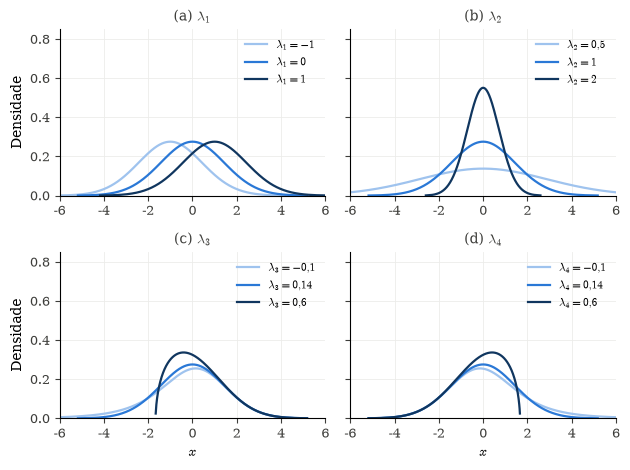

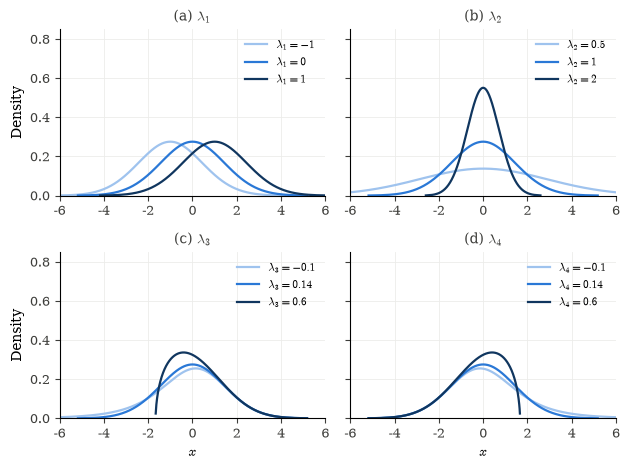

In [3]:
BASE = dict(lam1=0.0, lam2=1.0, lam3=0.14, lam4=0.14)
VARY = [('lam1', r'\lambda_1', [-1.0, 0.0, 1.0]),
        ('lam2', r'\lambda_2', [0.5, 1.0, 2.0]),
        ('lam3', r'\lambda_3', [-0.1, 0.14, 0.6]),
        ('lam4', r'\lambda_4', [-0.1, 0.14, 0.6])]
u = np.linspace(1e-4, 1 - 1e-4, 2000)


def density_curve(p):
    m = GlamFKML(**p)
    return m.ppf(u), 1.0 / m._gld_fkml_qprime(u, p['lam2'], p['lam3'], p['lam4'])


def plot_parameters(lang):
    fig, axes = plt.subplots(2, 2, figsize=(6.4, 4.8), sharey=True)
    shades = ['#9fc3ee', '#2a78d6', '#10365f']
    for ax, (key, sym, values), tag in zip(axes.flat, VARY, L[lang]['panels']):
        for v, c in zip(values, shades):
            x, f = density_curve({**BASE, key: v})
            ax.plot(x, f, color=c, linewidth=1.6, label=f'${sym} = {v:g}$'.replace('.', '{,}' if lang == 'pt' else '.'))
        ax.set_xlim(-6, 6)
        ax.set_ylim(0, 0.85)
        ax.set_title(f'{tag} ${sym}$', fontsize=10, color=ink)
        ax.legend(frameon=False, fontsize=8)
        style(ax)
    for ax in axes[:, 0]:
        ax.set_ylabel(L[lang]['dens'])
    for ax in axes[1]:
        ax.set_xlabel(L[lang]['x'])
    fig.tight_layout()
    save(fig, 'figura1_parametros', lang)
    return fig


for lang in ('pt', 'en'):
    plot_parameters(lang)
plt.show()

## **3. Dados**

Contagens da cópia local do arquivo. As médias diárias têm resolução de 0,1 m/s e 0,1 °C, o que
produz valores repetidos; a distância de Kolmogorov-Smirnov é usada como medida descritiva, sem
p-valor.

In [4]:
df = pd.read_csv(DATA, parse_dates=['data'])
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year

quality = pd.DataFrame({
    'registros': [len(df)] * 2,
    'valores válidos': [df['vento_ms'].notna().sum(), df['temperatura_c'].notna().sum()],
    'vazios': [df['vento_ms'].isna().sum(), df['temperatura_c'].isna().sum()],
    'zeros ou negativos': [(df['vento_ms'] <= 0).sum(), np.nan],
}, index=['vento_ms', 'temperatura_c'])
print('período:', df['data'].min().date(), 'a', df['data'].max().date(),
      '| datas repetidas:', df['data'].duplicated().sum())
display(quality)

wind = df.dropna(subset=['vento_ms'])
v    = wind['vento_ms'].to_numpy()
july = df[(df['mes'] == 7)].dropna(subset=['temperatura_c'])
t    = july['temperatura_c'].to_numpy()
print('julho:', len(t), 'dias válidos em', july['ano'].nunique(), 'anos',
      f"({july['ano'].min()} a {july['ano'].max()})")

período: 2000-05-06 a 2025-04-25 | datas repetidas: 0


,registros,valores válidos,vazios,zeros ou negativos
vento_ms,9121,8840,281,0.0
temperatura_c,9121,8781,340,NaN


julho: 768 dias válidos em 25 anos (2000 a 2024)


### 3.1 Estatísticas descritivas (Tabela 1)

Variância com divisor $n$ e curtose de Pearson (referência normal igual a 3), as mesmas
convenções do ajuste por momentos da `pyglam`.

In [5]:
def describe(x):
    m, s = x.mean(), x.std()                     # divisor n
    return {'n': len(x), 'média': m, 'mediana': np.median(x), 'desvio padrão': s,
            'CV': s / m, 'assimetria': st.skew(x), 'curtose': st.kurtosis(x, fisher=False),
            'mínimo': x.min(), 'máximo': x.max(),
            'Q05': np.quantile(x, 0.05), 'Q50': np.quantile(x, 0.50), 'Q95': np.quantile(x, 0.95)}


desc = pd.DataFrame({'vento (m/s)': describe(v), 'temperatura de julho (°C)': describe(t)})
display(desc.round(3))

,vento (m/s),temperatura de julho (°C)
n,8840.000,768.000
média,2.345,19.409
mediana,2.200,19.500
desvio padrão,0.711,1.466
CV,0.303,0.076
assimetria,0.738,-0.482
curtose,3.368,3.717
mínimo,0.700,14.000
máximo,5.500,23.200
Q05,1.400,16.835


## **4. Vento: ajustes**

In [6]:
def ks_distance(x, cdf):
    # D_n = sup |F_n - F| avaliada nos pontos da amostra, dos dois lados de cada degrau
    xs = np.sort(x)
    n  = xs.size
    F  = np.asarray(cdf(xs), dtype=float)
    i  = np.arange(1, n + 1)
    return float(max(np.max(i / n - F), np.max(F - (i - 1) / n)))


def fit_gld(x):
    sol = GlamFKML().fit_lambdas(x, n_starts=N_STARTS, seed=SEED)
    model = GlamFKML(*sol.x)
    lower, upper = model._support_bounds(tuple(sol.x))
    m_model = np.asarray(model._theoretical_moments(*sol.x))
    m_data  = np.asarray(GlamFKML().moments(x))
    info = {'lambda': sol.x, 'suporte': (lower, upper), 'custo': float(sol.costs[sol.best_start]),
            'momentos do modelo': m_model, 'momentos da amostra': m_data,
            'candidatos válidos': int(np.sum(sol.monotone)), 'candidatos': int(sol.n_starts)}
    return model, info


PROBS = np.array([0.05, 0.50, 0.95])
q_v   = np.quantile(v, PROBS)

sigma_r  = np.sqrt(np.sum(v**2) / (2 * len(v)))              # máxima verossimilhança
rayleigh = st.rayleigh(scale=sigma_r)
k_w, _, c_w = st.weibull_min.fit(v, floc=0)                   # máxima verossimilhança, origem em zero
weibull  = st.weibull_min(k_w, scale=c_w)
gld_v, info_v = fit_gld(v)

print(f'Rayleigh: sigma = {sigma_r:.4f} m/s | CV teórico = {np.sqrt((4 - np.pi) / np.pi):.3f}'
      f' | CV amostral = {v.std() / v.mean():.3f}')
print(f'Weibull: forma k = {k_w:.4f}, escala c = {c_w:.4f} m/s')
print('GLD:', {k: np.round(val, 4) for k, val in info_v.items()})
print(f'GLD: P(V < 0) = {float(gld_v.cdf(0.0)) if info_v["suporte"][0] < 0 else 0.0:.2e}')

Rayleigh: sigma = 1.7331 m/s | CV teórico = 0.523 | CV amostral = 0.303
Weibull: forma k = 3.4484, escala c = 2.6052 m/s
GLD: {'lambda': array([2.1907, 1.727 , 0.5555, 0.0987]), 'suporte': array([1.1482, 8.0572]), 'custo': np.float64(0.0), 'momentos do modelo': array([2.3455, 0.5059, 0.7379, 3.3677]), 'momentos da amostra': array([2.3455, 0.5059, 0.7379, 3.3677]), 'candidatos válidos': np.int64(15), 'candidatos': np.int64(15)}
GLD: P(V < 0) = 0.00e+00


In [7]:
def performance(x, q_emp, models):
    rows = []
    for name, (k, cdf, ppf) in models.items():
        rows.append({'modelo': name, 'parâmetros': k, 'D_n': ks_distance(x, cdf),
                     **{f'Delta_{p:g}': d for p, d in zip(PROBS, ppf(PROBS) - q_emp)}})
    return pd.DataFrame(rows)


perf_v = performance(v, q_v, {
    'Rayleigh': (1, rayleigh.cdf, rayleigh.ppf),
    'Weibull':  (2, weibull.cdf, weibull.ppf),
    'GLD-FKML': (4, gld_v.cdf, gld_v.ppf),
})
display(perf_v.round(4))

,modelo,parâmetros,D_n,Delta_0.05,Delta_0.5,Delta_0.95
0,Rayleigh,1,0.2422,-0.8449,-0.1594,0.5422
1,Weibull,2,0.0853,-0.2990,0.1425,-0.1189
2,GLD-FKML,4,0.0410,-0.0247,0.0455,-0.0368


### 4.1 Figuras 2 e 3

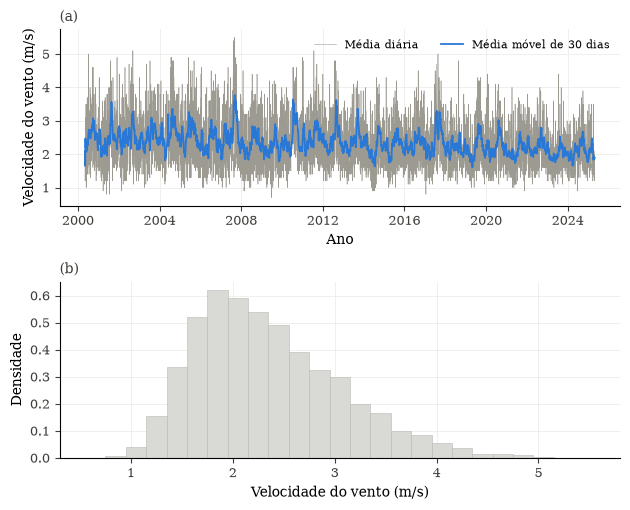

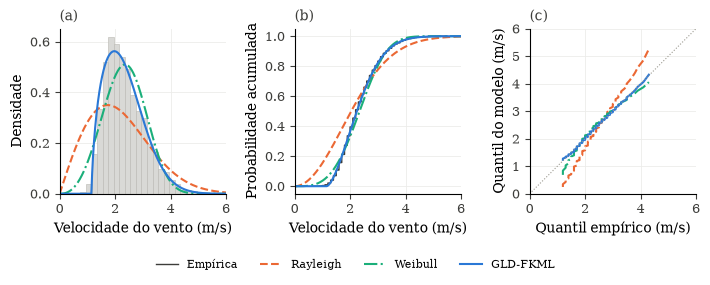

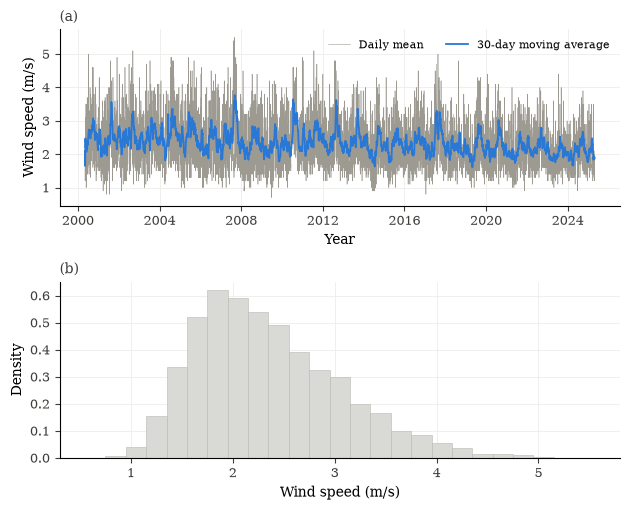

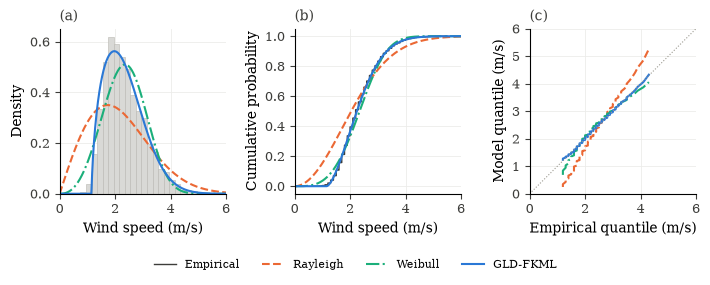

In [8]:
def plot_wind_overview(lang):
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.4, 5.2))
    a1.plot(wind['data'], wind['vento_ms'], color=color['data'], linewidth=0.4, label=L[lang]['daily'])
    roll = wind.set_index('data')['vento_ms'].rolling('30D').mean()
    a1.plot(roll.index, roll.values, color=color['gld'], linewidth=1.3, label=L[lang]['roll'])
    a1.set_ylabel(L[lang]['wind'])
    a1.set_xlabel(L[lang]['year'])
    a1.set_title('(a)', fontsize=10, color=ink, loc='left')
    a1.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')
    a2.hist(v, bins=np.arange(0.55, 5.66, 0.2), density=True, color=hist_face, edgecolor='#b9b8b2', linewidth=0.4)
    a2.set_xlabel(L[lang]['wind'])
    a2.set_ylabel(L[lang]['dens'])
    a2.set_title('(b)', fontsize=10, color=ink, loc='left')
    for ax in (a1, a2):
        style(ax)
    fig.tight_layout()
    save(fig, 'figura2_vento_exploratoria', lang)
    return fig


def plot_diagnostics(x, models, unit_label, name, lang, xlim, bins):
    fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.7))
    grid = np.linspace(*xlim, 600)
    axes[0].hist(x, bins=bins, density=True, color=hist_face, edgecolor='#b9b8b2', linewidth=0.4,
                 label=L[lang]['sample'])
    xs = np.sort(x)
    axes[1].step(xs, np.arange(1, xs.size + 1) / xs.size, where='post', color=ink, linewidth=1.0,
                 label=L[lang]['ecdf'])
    p = (np.arange(1, 100)) / 100
    q_emp = np.quantile(x, p)
    for key, (dist, ls) in models.items():
        c = color[key]
        axes[0].plot(grid, dist.pdf(grid), color=c, linestyle=ls, linewidth=1.5, label=L[lang][key])
        axes[1].plot(grid, dist.cdf(grid), color=c, linestyle=ls, linewidth=1.5, label=L[lang][key])
        axes[2].plot(q_emp, dist.ppf(p), color=c, linestyle=ls, linewidth=1.5, label=L[lang][key])
    axes[2].plot(xlim, xlim, color='#9c9a91', linewidth=0.8, linestyle=':')
    axes[0].set_ylabel(L[lang]['dens'])
    axes[1].set_ylabel(L[lang]['cdf'])
    axes[2].set_ylabel(L[lang]['q_model'] + f' ({unit_label})')
    axes[2].set_xlabel(L[lang]['q_emp'] + f' ({unit_label})')
    for ax, tag in zip(axes, ('(a)', '(b)', '(c)')):
        if ax is not axes[2]:
            ax.set_xlabel(L[lang]['wind'] if unit_label == 'm/s' else L[lang]['temp'])
        ax.set_xlim(*xlim)
        ax.set_title(tag, fontsize=10, color=ink, loc='left')
        style(ax)
    axes[2].set_ylim(*xlim)
    h, lb = axes[1].get_legend_handles_labels()
    fig.legend(h, lb, frameon=False, fontsize=8, ncol=len(lb), loc='lower center',
               bbox_to_anchor=(0.5, -0.06))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    save(fig, name, lang)
    return fig


for lang in ('pt', 'en'):
    plot_wind_overview(lang)
    plot_diagnostics(v, {'rayleigh': (rayleigh, '--'), 'weibull': (weibull, '-.'), 'gld': (gld_v, '-')},
                     'm/s', 'figura3_vento_diagnosticos', lang, (0.0, 6.0), np.arange(0.55, 5.66, 0.2))
plt.show()

## **5. Temperatura de julho: ajustes e Figuras 4 e 5**

In [9]:
q_t = np.quantile(t, PROBS)
mu_n, sd_n = st.norm.fit(t)                                  # máxima verossimilhança (divisor n)
normal = st.norm(mu_n, sd_n)
gld_t, info_t = fit_gld(t)

print(f'Normal: mu = {mu_n:.4f} °C, sigma = {sd_n:.4f} °C')
print('GLD:', {k: np.round(val, 4) for k, val in info_t.items()})

perf_t = performance(t, q_t, {
    'Normal':   (2, normal.cdf, normal.ppf),
    'GLD-FKML': (4, gld_t.cdf, gld_t.ppf),
})
display(perf_t.round(4))

Normal: mu = 19.4092 °C, sigma = 1.4658 °C
GLD: {'lambda': array([1.9538e+01, 1.0706e+00, 1.7500e-02, 1.8360e-01]), 'suporte': array([-33.855 ,  24.6263]), 'custo': np.float64(0.0), 'momentos do modelo': array([19.4092,  2.1486, -0.4818,  3.7168]), 'momentos da amostra': array([19.4092,  2.1486, -0.4818,  3.7168]), 'candidatos válidos': np.int64(15), 'candidatos': np.int64(15)}


,modelo,parâmetros,D_n,Delta_0.05,Delta_0.5,Delta_0.95
0,Normal,2,0.0642,0.1632,-0.0908,0.1203
1,GLD-FKML,4,0.0408,0.0247,0.0025,-0.0575


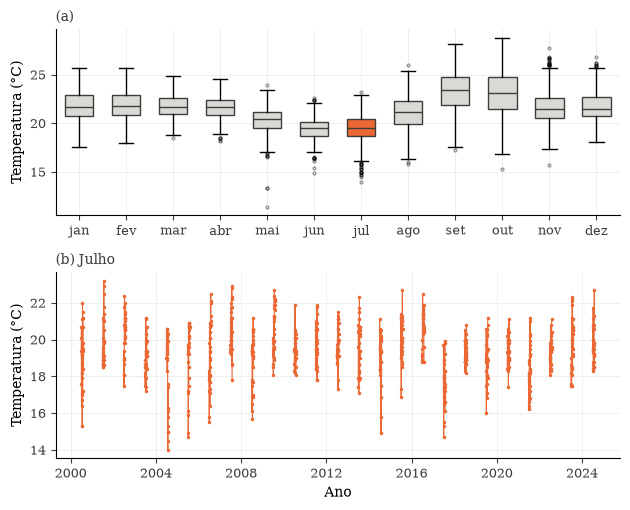

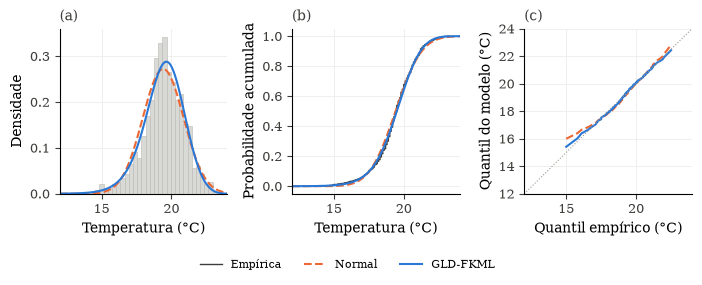

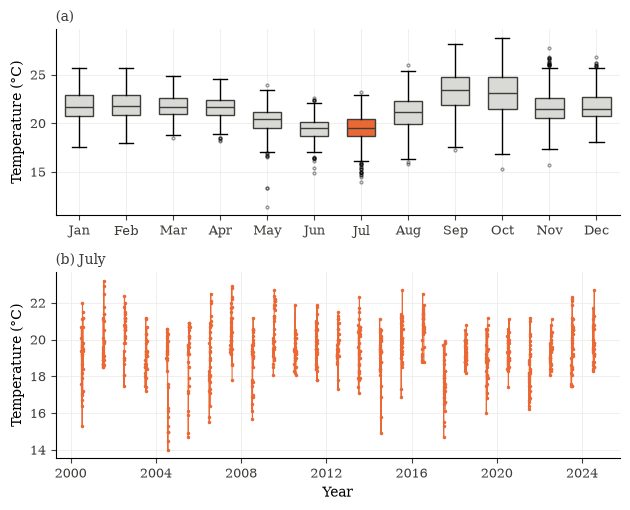

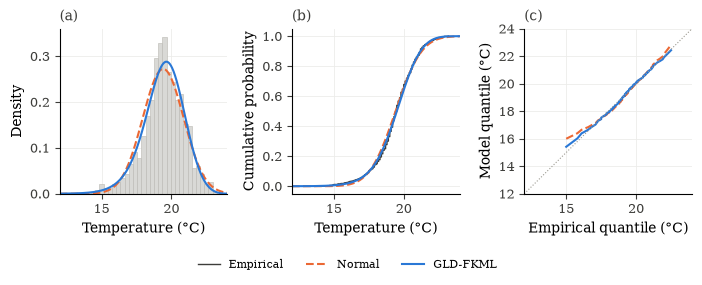

In [10]:
def plot_temperature_overview(lang):
    temp = df.dropna(subset=['temperatura_c'])
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.4, 5.2))
    data = [temp.loc[temp['mes'] == m, 'temperatura_c'] for m in range(1, 13)]
    bp = a1.boxplot(data, patch_artist=True, widths=0.6, flierprops=dict(markersize=2, alpha=0.4),
                    medianprops=dict(color=ink))
    for m, box in enumerate(bp['boxes'], start=1):
        box.set_facecolor(color['july'] if m == 7 else hist_face)
        box.set_edgecolor(ink)
    a1.set_xticks(range(1, 13), L[lang]['months'])
    a1.set_ylabel(L[lang]['temp'])
    a1.set_title('(a)', fontsize=10, color=ink, loc='left')
    for year, d in july.groupby('ano'):
        a2.plot(d['data'], d['temperatura_c'], color=color['july'], linewidth=0.8, marker='o', markersize=1.5)
    a2.set_ylabel(L[lang]['temp'])
    a2.set_xlabel(L[lang]['year'])
    a2.set_title('(b) ' + L[lang]['july'], fontsize=10, color=ink, loc='left')
    for ax in (a1, a2):
        style(ax)
    fig.tight_layout()
    save(fig, 'figura4_temperatura_sazonalidade', lang)
    return fig


for lang in ('pt', 'en'):
    plot_temperature_overview(lang)
    plot_diagnostics(t, {'normal': (normal, '--'), 'gld': (gld_t, '-')},
                     '°C', 'figura5_temperatura_diagnosticos', lang, (12.0, 24.0), np.arange(13.95, 23.36, 0.3))
plt.show()

## **6. Tabelas em LaTeX**

In [11]:
def fmt(x, d=3, sign=False):
    s = f'{x:+.{d}f}' if sign else f'{x:.{d}f}'
    return s.replace('.', '{,}')


def fmt_int(n):
    return f'{int(n):,}'.replace(',', '.')


rows = [('$n$', lambda c: fmt_int(desc.loc['n', c])),
        ('Média', lambda c: fmt(desc.loc['média', c], 3)),
        ('Mediana', lambda c: fmt(desc.loc['mediana', c], 2)),
        ('Desvio padrão', lambda c: fmt(desc.loc['desvio padrão', c], 3)),
        ('Coeficiente de variação', lambda c: fmt(desc.loc['CV', c], 3)),
        ('Assimetria', lambda c: fmt(desc.loc['assimetria', c], 3)),
        ('Curtose (Pearson)', lambda c: fmt(desc.loc['curtose', c], 3)),
        ('Mínimo; máximo', lambda c: fmt(desc.loc['mínimo', c], 1) + '; ' + fmt(desc.loc['máximo', c], 1)),
        ('$Q_{0{,}05}$; $Q_{0{,}50}$; $Q_{0{,}95}$',
         lambda c: '; '.join(fmt(desc.loc[k, c], 2) for k in ('Q05', 'Q50', 'Q95')))]
body = '\n'.join(f'{label} & ' + ' & '.join(f(c) for c in desc.columns) + r' \\' for label, f in rows)
(OUT / 'tab_descritiva.tex').write_text(body.rstrip(' \\') + '\n', encoding='utf-8')


def perf_table(perf, d=3):
    lines = [f"{r['modelo']} & {r['parâmetros']} & {fmt(r['D_n'], 3)} & "
             + ' & '.join(fmt(r[f'Delta_{p:g}'], d, sign=True) for p in PROBS) + r' \\'
             for _, r in perf.iterrows()]
    return '\n'.join(lines).rstrip(' \\') + '\n'


(OUT / 'tab_vento.tex').write_text(perf_table(perf_v), encoding='utf-8')
(OUT / 'tab_temperatura.tex').write_text(perf_table(perf_t), encoding='utf-8')
for name in ('tab_descritiva', 'tab_vento', 'tab_temperatura'):
    print(f'--- {name}'); print((OUT / f'{name}.tex').read_text(encoding='utf-8'))

--- tab_descritiva
$n$ & 8.840 & 768 \\
Média & 2{,}345 & 19{,}409 \\
Mediana & 2{,}20 & 19{,}50 \\
Desvio padrão & 0{,}711 & 1{,}466 \\
Coeficiente de variação & 0{,}303 & 0{,}076 \\
Assimetria & 0{,}738 & -0{,}482 \\
Curtose (Pearson) & 3{,}368 & 3{,}717 \\
Mínimo; máximo & 0{,}7; 5{,}5 & 14{,}0; 23{,}2 \\
$Q_{0{,}05}$; $Q_{0{,}50}$; $Q_{0{,}95}$ & 1{,}40; 2{,}20; 3{,}70 & 16{,}84; 19{,}50; 21{,}70

--- tab_vento
Rayleigh & 1 & 0{,}242 & -0{,}845 & -0{,}159 & +0{,}542 \\
Weibull & 2 & 0{,}085 & -0{,}299 & +0{,}142 & -0{,}119 \\
GLD-FKML & 4 & 0{,}041 & -0{,}025 & +0{,}046 & -0{,}037

--- tab_temperatura
Normal & 2 & 0{,}064 & +0{,}163 & -0{,}091 & +0{,}120 \\
GLD-FKML & 4 & 0{,}041 & +0{,}025 & +0{,}002 & -0{,}058

